In [1]:
from graph import GraphBuilder, KnowledgeGraph
from concept import ConceptGraph
import pandas as pd
import numpy as np


/people/boufouss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
builder = GraphBuilder(device = 'cuda:0')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

## Generation Graphe

In [12]:
P = builder.build("He eats chicken.")
H = builder.build("He eats meat.")

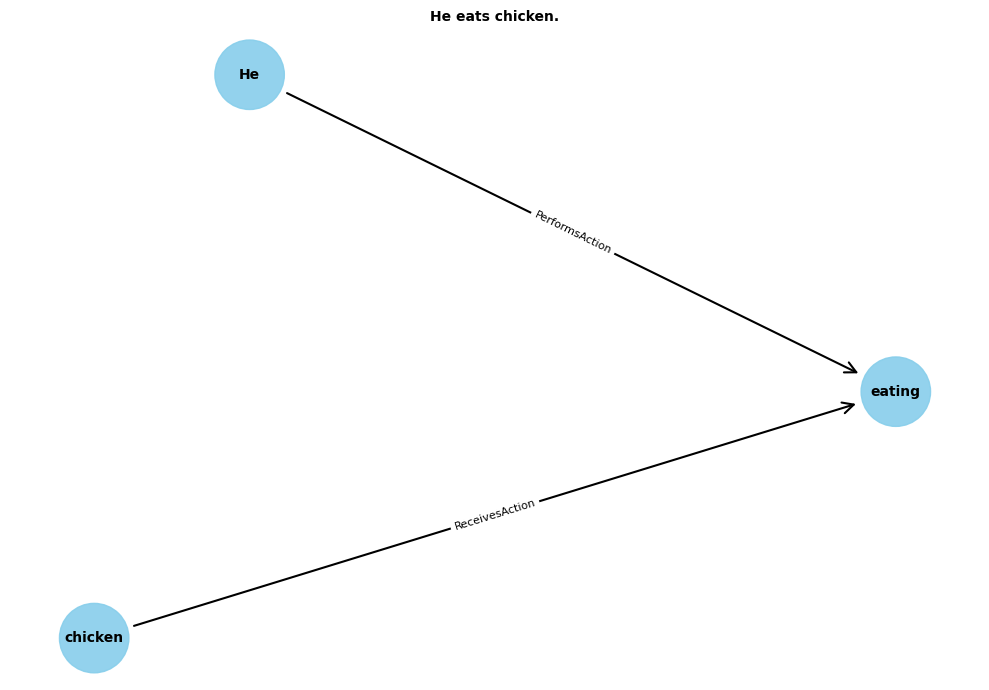

In [4]:
P.display()

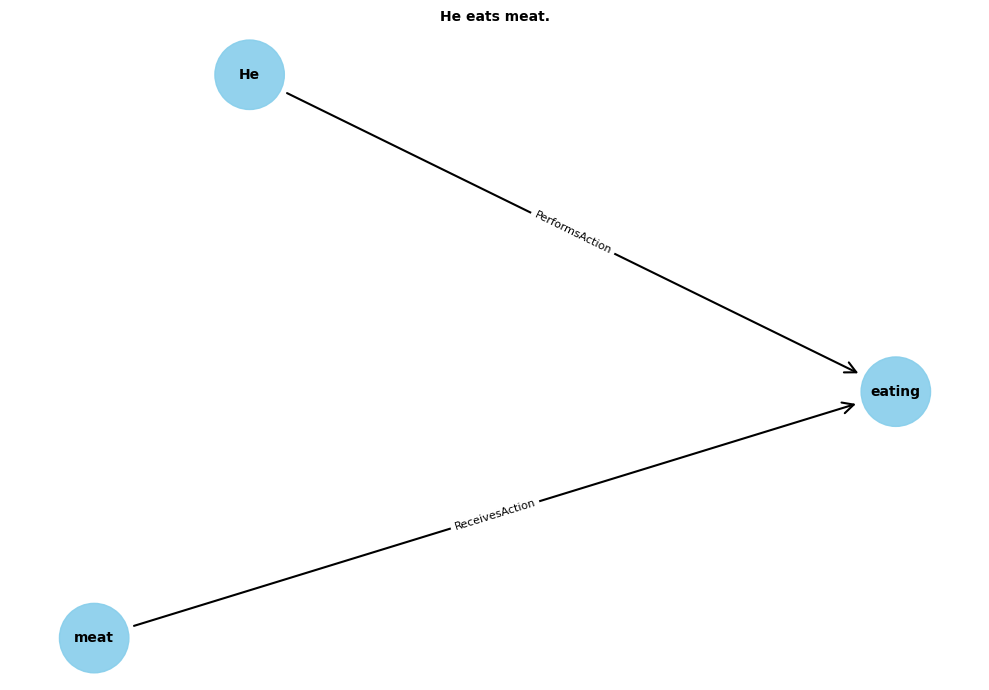

In [5]:
H.display()

## Test recuperer des données

In [6]:
conceptGraph = ConceptGraph('en', device = 'cuda:0')
## ConceptGraph.get_rel_forward('ability')

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
data_p = conceptGraph.get_rel_naive(P, dist = 1)
data_p[:8], data_p.shape

(array([['chicken', 'RelatedTo', 'bird', 10.768],
        ['eating', 'RelatedTo', 'plate', 9.978],
        ['chicken', 'RelatedTo', 'egg', 9.406],
        ['chicken', 'RelatedTo', 'hen', 8.103],
        ['chicken', 'RelatedTo', 'rooster', 7.657],
        ['chicken', 'RelatedTo', 'animal', 7.6],
        ['chicken', 'CapableOf', 'cross_road', 7.483],
        ['chicken', 'IsA', 'food', 7.211]], dtype=object),
 (90, 4))

Les relations avec le score le plus elevé ne sont pas forcement les plus pertinentes pour lier P à H.

In [8]:
data_p_similarity = conceptGraph.similarity_score(H,data_p)
data_p_similarity, data_p_similarity.shape

(array([['chicken', 'RelatedTo', 'meat', 5.759, -5.684865951538086],
        ['chicken', 'IsA', 'meat', 6.633, -6.086508750915527],
        ['eating', 'HasPrerequisite', 'food', 2.828, -6.727169036865234],
        ['chicken', 'RelatedTo', 'eating', 3.394, -6.965595245361328],
        ['chicken', 'RelatedTo', 'white_meat', 2.542, -7.026357650756836],
        ['eating', 'RelatedTo', 'chicken', 3.394, -7.292215347290039],
        ['eating', 'HasSubevent', 'chewing', 7.211, -7.569958686828613],
        ['eating', 'HasSubevent', 'swallow', 2.828, -7.75788688659668],
        ['eating', 'HasSubevent', 'bite', 2.0, -7.787076950073242],
        ['eating', 'HasSubevent', 'chew', 2.0, -7.878334999084473],
        ['eating', 'IsA', 'way', 2.0, -7.959181308746338],
        ['eating', 'HasSubevent', 'choking', 2.0, -8.103548049926758],
        ['eating', 'HasPrerequisite', 'chewing', 2.0, -8.223419189453125],
        ['eating', 'RelatedTo', 'mouth', 3.149, -8.2779541015625],
        ['chicken', 'Rel

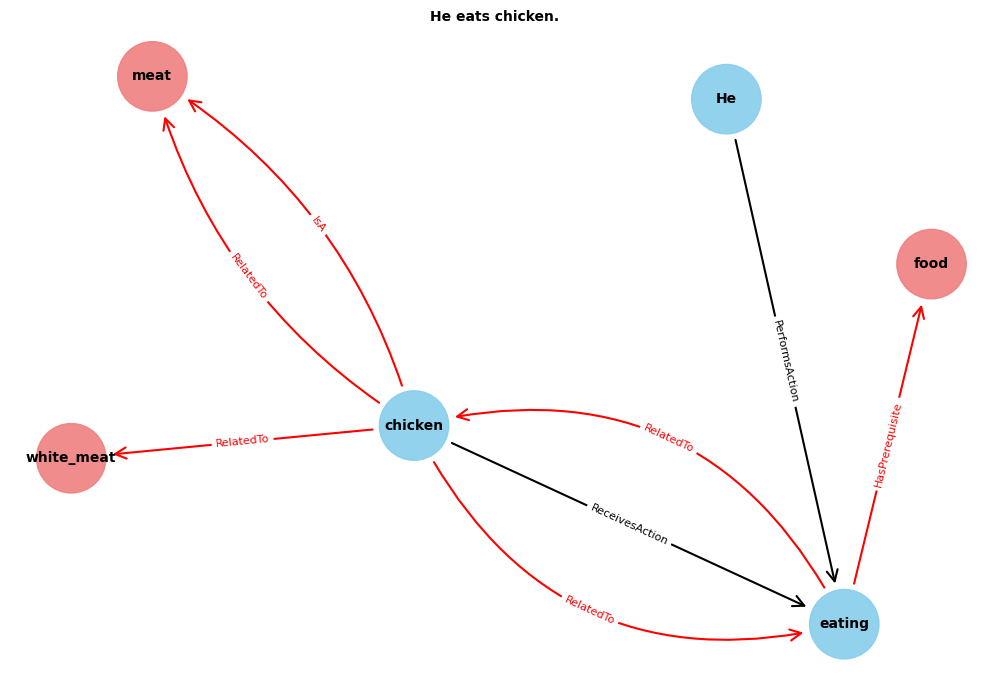

In [13]:
P.augment([(line[0],line[1],line[2])for line in data_p_similarity][:6])
P.display()


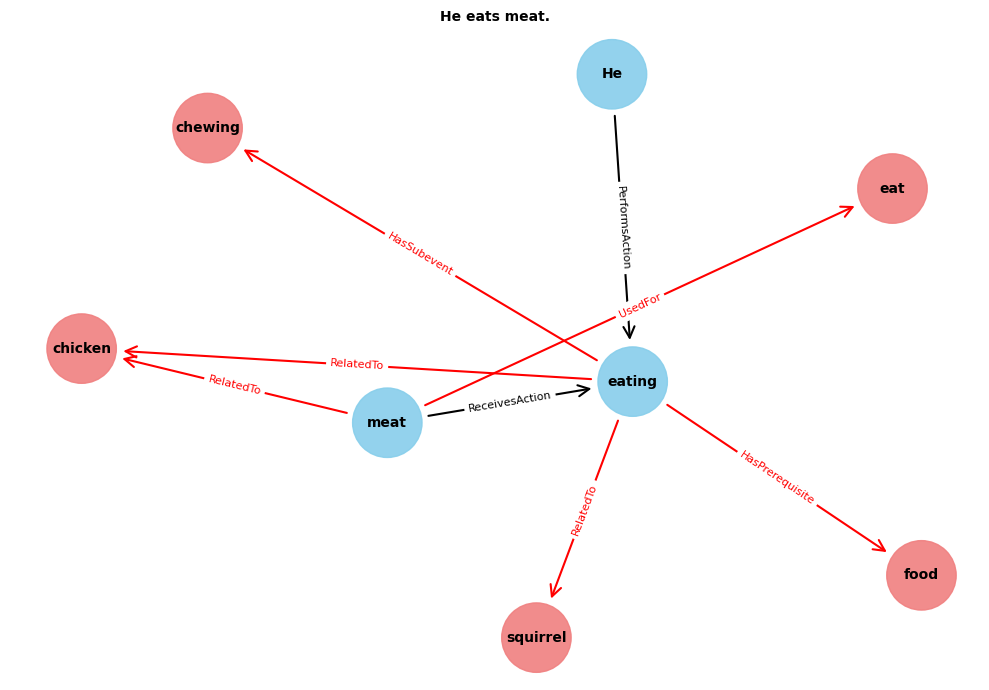

In [14]:
data_h = conceptGraph.get_rel_naive(H,dist = 1)
data_h_similarity = conceptGraph.similarity_score(P,data_h)
H.augment([(line[0],line[1],line[2])for line in data_h_similarity][:6])
H.display()